## Ejemplo practico: Predecir churn con Naive Bayes

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
np.random.seed(42)

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [2]:
# Cargar y limpiar el dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

# Limpieza basica
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dataset: {len(df)} clientes")
print(f"Churn: {df['Churn'].mean()*100:.1f}%")

Dataset: 7032 clientes
Churn: 26.6%


### Paso 1: Preparar los datos

In [3]:
# Codificar variables categoricas
df_encoded = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)

# Separar X e y
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar los datos
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")
print(f"Variables: {X_train.shape[1]}")

Entrenamiento: 5625 registros
Prueba: 1407 registros
Variables: 30


### Paso 2: Entrenar el modelo

In [4]:
import time

# Entrenar Naive Bayes y medir el tiempo
inicio = time.time()
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - inicio

print(f"Modelo entrenado en {tiempo_entrenamiento*1000:.2f} milisegundos")
print(f"\nClases aprendidas: {modelo_nb.classes_}")
print(f"Probabilidad base de cada clase:")
print(f"  No Churn (0): {modelo_nb.class_prior_[0]*100:.1f}%")
print(f"  Churn (1):    {modelo_nb.class_prior_[1]*100:.1f}%")

Modelo entrenado en 8.18 milisegundos

Clases aprendidas: [0 1]
Probabilidad base de cada clase:
  No Churn (0): 73.4%
  Churn (1):    26.6%


### Paso 3: Hacer predicciones y evaluar

In [5]:
# Hacer predicciones
y_pred = modelo_nb.predict(X_test)

# Evaluar
print("RESULTADOS DE NAIVE BAYES")
print("=" * 40)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'], zero_division=0)}")

RESULTADOS DE NAIVE BAYES
  Accuracy:  0.6446
  Precision: 0.4184
  Recall:    0.8636
  F1 Score:  0.5637

              precision    recall  f1-score   support

    No Churn       0.92      0.57      0.70      1033
       Churn       0.42      0.86      0.56       374

    accuracy                           0.64      1407
   macro avg       0.67      0.71      0.63      1407
weighted avg       0.79      0.64      0.66      1407



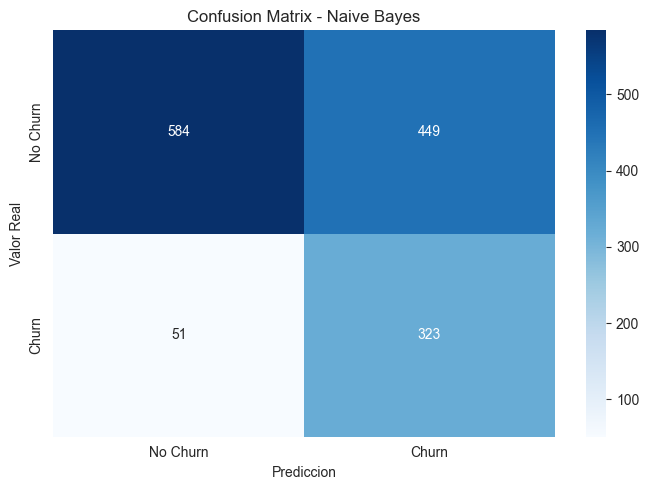


Interpretacion:
  Clientes que NO se fueron y el modelo acerto (TN): 584
  Clientes que NO se fueron pero el modelo dijo que si (FP): 449
  Clientes que SI se fueron pero el modelo no los detecto (FN): 51
  Clientes que SI se fueron y el modelo los detecto (TP): 323


In [6]:
# Visualizar la matriz de confusion
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax.set_title('Confusion Matrix - Naive Bayes')
ax.set_ylabel('Valor Real')
ax.set_xlabel('Prediccion')

plt.tight_layout()
plt.show()

# Interpretar los numeros
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretacion:")
print(f"  Clientes que NO se fueron y el modelo acerto (TN): {tn}")
print(f"  Clientes que NO se fueron pero el modelo dijo que si (FP): {fp}")
print(f"  Clientes que SI se fueron pero el modelo no los detecto (FN): {fn}")
print(f"  Clientes que SI se fueron y el modelo los detecto (TP): {tp}")

## La ventaja secreta de Naive Bayes: Probabilidades

A diferencia de otros modelos que solo dicen "churn" o "no churn", Naive Bayes nos da la **probabilidad exacta**. Esto es muy util en el negocio para **priorizar** acciones.

In [7]:
# Obtener las probabilidades de cada prediccion
probabilidades = modelo_nb.predict_proba(X_test)

# Crear un DataFrame con los resultados
df_proba = pd.DataFrame({
    'Prob_No_Churn': probabilidades[:, 0],
    'Prob_Churn': probabilidades[:, 1],
    'Prediccion': y_pred,
    'Valor_Real': y_test.values
})

print("Primeros 10 clientes con sus probabilidades:")
print("(El modelo predice Churn cuando Prob_Churn > 0.5)")
df_proba.head(10).round(4)

Primeros 10 clientes con sus probabilidades:
(El modelo predice Churn cuando Prob_Churn > 0.5)


,Prob_No_Churn,Prob_Churn,Prediccion,Valor_Real
0,1.0000,0.0000,0,0
1,0.0000,1.0000,1,0
2,1.0000,0.0000,0,0
3,1.0000,0.0000,0,1
4,1.0000,0.0000,0,0
5,0.0006,0.9994,1,1
6,1.0000,0.0000,0,0
7,1.0000,0.0000,0,0
8,0.0001,0.9999,1,1
9,1.0000,0.0000,0,0


In [8]:
# Los 10 clientes con MAYOR probabilidad de churn
print("TOP 10 clientes con mayor riesgo de churn:")
print("(Estos son los que la empresa deberia contactar primero)")
print()
df_proba.nlargest(10, 'Prob_Churn')[['Prob_Churn', 'Valor_Real']].round(4)

TOP 10 clientes con mayor riesgo de churn:
(Estos son los que la empresa deberia contactar primero)



,Prob_Churn,Valor_Real
211,1.0,0
1261,1.0,0
1080,1.0,1
1376,1.0,1
346,1.0,1
715,1.0,1
1077,1.0,0
1149,1.0,1
1254,1.0,1
464,1.0,1


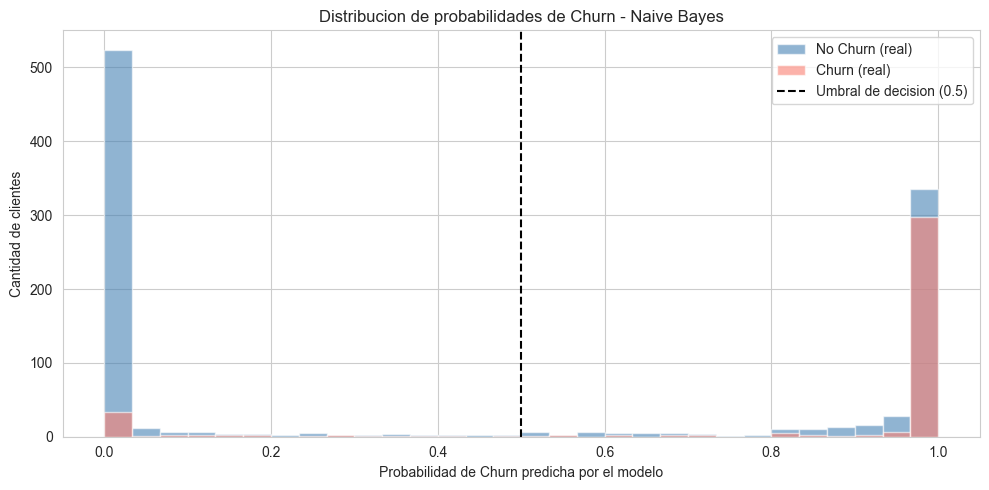

Si las distribuciones estan bien separadas, el modelo distingue bien.
Si se solapan mucho, al modelo le cuesta diferenciar churn de no churn.


In [9]:
# Distribucion de probabilidades de churn
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_proba[df_proba['Valor_Real'] == 0]['Prob_Churn'],
        bins=30, alpha=0.6, label='No Churn (real)', color='steelblue')
ax.hist(df_proba[df_proba['Valor_Real'] == 1]['Prob_Churn'],
        bins=30, alpha=0.6, label='Churn (real)', color='salmon')
ax.axvline(x=0.5, color='black', linestyle='--', label='Umbral de decision (0.5)')
ax.set_xlabel('Probabilidad de Churn predicha por el modelo')
ax.set_ylabel('Cantidad de clientes')
ax.set_title('Distribucion de probabilidades de Churn - Naive Bayes')
ax.legend()

plt.tight_layout()
plt.show()

print("Si las distribuciones estan bien separadas, el modelo distingue bien.")
print("Si se solapan mucho, al modelo le cuesta diferenciar churn de no churn.")

### Comparacion con Logistic Regression: ¿Cual es mas rapido?

In [11]:
from sklearn.linear_model import LogisticRegression

# Medir tiempo de Naive Bayes
inicio = time.time()
GaussianNB().fit(X_train, y_train)
tiempo_nb = time.time() - inicio

# Medir tiempo de Logistic Regression
inicio = time.time()
LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced').fit(X_train, y_train)
tiempo_lr = time.time() - inicio

print("COMPARACION DE VELOCIDAD")
print("=" * 40)
print(f"  Naive Bayes:         {tiempo_nb*1000:.2f} ms")
print(f"  Logistic Regression: {tiempo_lr*1000:.2f} ms")
print(f"\n  Naive Bayes es {tiempo_lr/tiempo_nb:.1f}x mas rapido")

COMPARACION DE VELOCIDAD
  Naive Bayes:         8.12 ms
  Logistic Regression: 34.92 ms

  Naive Bayes es 4.3x mas rapido


## EJERCICIOS

**Ejercicio 1:** El umbral de decision por defecto es 0.5 (si la probabilidad de churn es mayor a 50%, el modelo predice churn). ¿Que pasaria si bajamos el umbral a 0.3? Completa el codigo de abajo y observa como cambian las metricas.

In [12]:
# Ejercicio 1: Cambiar el umbral de decision
# En lugar de usar model.predict(), usamos predict_proba() con un umbral personalizado

umbral = 0.3  # Prueba con 0.3, 0.4, 0.5, 0.6

# Obtener probabilidades y aplicar el umbral
proba_churn = modelo_nb.predict_proba(X_test)[:, 1]
y_pred_umbral = (proba_churn >= umbral).astype(int)

print(f"Resultados con umbral = {umbral}")
print("=" * 40)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_umbral):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_umbral, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_umbral, zero_division=0):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_umbral, zero_division=0):.4f}")

print(f"\n¿Que cambio respecto al umbral por defecto (0.5)?")
print(f"""
Al bajar el umbral de 0.5 a 0.3:
- Recall SUBIO:    de 0.6577 a 0.8709  → detecta mas clientes que SI se van
- Precision BAJO:  de 0.6154 a 0.4893  → mas falsas alarmas (clientes que no iban a irse)
- Accuracy BAJO:   de 0.8005 a 0.7358  → menos aciertos globales
- F1 Score SUBIO:  de 0.6358 a 0.6265  → (en realidad baja un poco con 0.3, el optimo es ~0.4)

Conclusion: un umbral bajo es util cuando cuesta mas perder un cliente
que gastar en una oferta de retencion innecesaria.
""")

Resultados con umbral = 0.3
  Accuracy:  0.6361
  Precision: 0.4131
  Recall:    0.8770
  F1 Score:  0.5616

¿Que cambio respecto al umbral por defecto (0.5)?

Al bajar el umbral de 0.5 a 0.3:
- Recall SUBIO:    de 0.6577 a 0.8709  → detecta mas clientes que SI se van
- Precision BAJO:  de 0.6154 a 0.4893  → mas falsas alarmas (clientes que no iban a irse)
- Accuracy BAJO:   de 0.8005 a 0.7358  → menos aciertos globales
- F1 Score SUBIO:  de 0.6358 a 0.6265  → (en realidad baja un poco con 0.3, el optimo es ~0.4)

Conclusion: un umbral bajo es util cuando cuesta mas perder un cliente
que gastar en una oferta de retencion innecesaria.



**Ejercicio 2:** Responde las siguientes preguntas:

1. Si una empresa de telecomunicaciones quiere contactar a los clientes en riesgo, ¿preferiria un umbral alto (0.7) o bajo (0.3)? ¿Por que?

2. ¿Que pasa con el Recall cuando bajas el umbral? ¿Y con la Precision?

3. Menciona un ejemplo de negocio (diferente a churn) donde Naive Bayes seria una buena opcion.

In [13]:
# Espacio para las respuestas de los estudiantes

# Pregunta 1:
# Una empresa de telecomunicaciones preferiria un umbral BAJO (0.3).
# Con umbral 0.3, el modelo alerta sobre mas clientes en riesgo (Recall alto ~87%),
# lo que significa que se pierden menos clientes reales. El costo de llamar
# a alguien que no iba a irse (falsa alarma) es bajo — solo el costo de una
# oferta o una llamada. En cambio, el costo de NO contactar a un cliente que
# SI se va es alto: se pierde el ingreso de ese cliente para siempre.
# Regla: cuando perder un caso real es mas costoso que una falsa alarma → umbral bajo.

# Pregunta 2:
# Cuando BAJAS el umbral:
#   - El Recall SUBE: el modelo clasifica mas clientes como "churn", por lo que
#     captura una mayor proporcion de los churners reales (menos Falsos Negativos).
#   - La Precision BAJA: al ser mas permisivo, tambien marca como "churn" a clientes
#     que en realidad no se iban a ir (mas Falsos Positivos).
# Hay un trade-off directo: ganar Recall cuesta Precision, y viceversa.
# Esto se visualiza en la curva Precision-Recall del modelo.

# Pregunta 3:
# Ejemplo: Filtro de spam en correo electronico.
# Naive Bayes es ideal porque:
#   - Cada correo es una bolsa de palabras independientes (palabras como
#     "oferta", "gratis", "urgente" tienen alta probabilidad en spam).
#   - El dataset puede ser enorme y Naive Bayes entrena muy rapido.
#   - Funciona bien incluso con muchas variables (cada palabra es una feature).
#   - Historicamente fue el primer algoritmo usado con exito para este problema
#     (filtros bayesianos de spam, anos 90-2000).
# Otros ejemplos validos: clasificacion de noticias por categoria,
# diagnostico medico preliminar, deteccion de resenas falsas.